In [1]:
import os
import pathlib

import numpy as np
import scipy as sp
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import pingouin as pg


import STX3KO_analyses as stx
u = stx.utilities

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['font.serif'] = 'Arial'

%matplotlib inline

%load_ext autoreload
%autoreload 2


In [2]:
figdir = pathlib.Path('/mnt/BigDisk/fig_scratch/stx3/fig2_naive_bayes')
figdir.mkdir(exist_ok=True, parents=True)


{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 8, 'novel_arm': -1, 'ravel_ind': 0}
{'date': '03_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 4}


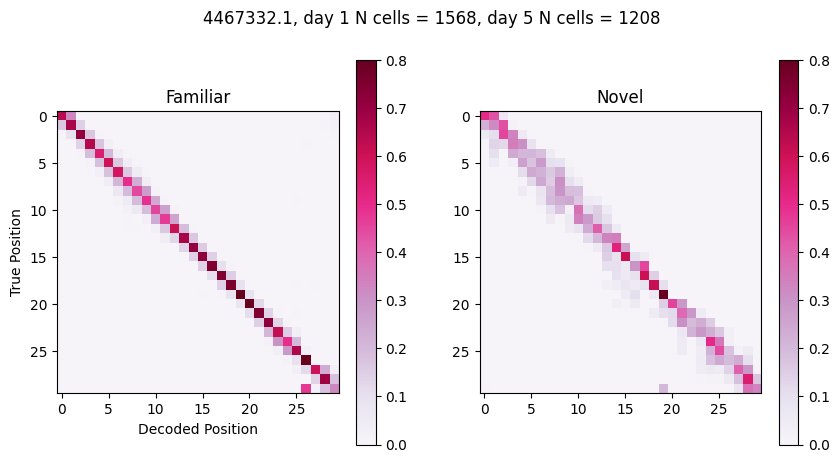

In [3]:
fig, ax = plt.subplots(1,2, figsize= [10, 5])
mouse = ctrl_mice[2]

sess = u.load_single_day(mouse,0)
nov_post = stx.naive_bayes.crossval(sess,nov=True)
ncells_0 = sess.timeseries['F_dff'].shape[0]

sess = u.load_single_day(mouse,4)
fam_post = stx.naive_bayes.crossval(sess,nov=False)
ncells_4 = sess.timeseries['F_dff'].shape[0]
    
h = ax[0].imshow(fam_post.mean(axis=0), cmap='PuRd', vmin=0,vmax=.8)
plt.colorbar(h, ax = ax[0], shrink=1.)
h = ax[1].imshow(nov_post.mean(axis=0), cmap='PuRd', vmin=0,vmax=.8)
plt.colorbar(h, ax = ax[1], shrink =1.)


fig.suptitle(f"{mouse}, day 1 N cells = {ncells_0}, day 5 N cells = {ncells_4}")
ax[0].set_title("Familiar")
ax[0].set_xlabel('Decoded Position')
ax[0].set_ylabel('True Position')

ax[1].set_title("Novel")

fig.savefig(figdir / f"{mouse}_naive_bayes_examples.pdf", bbox_inches='tight')

{'date': '28_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'ravel_ind': 0}


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


{'date': '02_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 4}


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


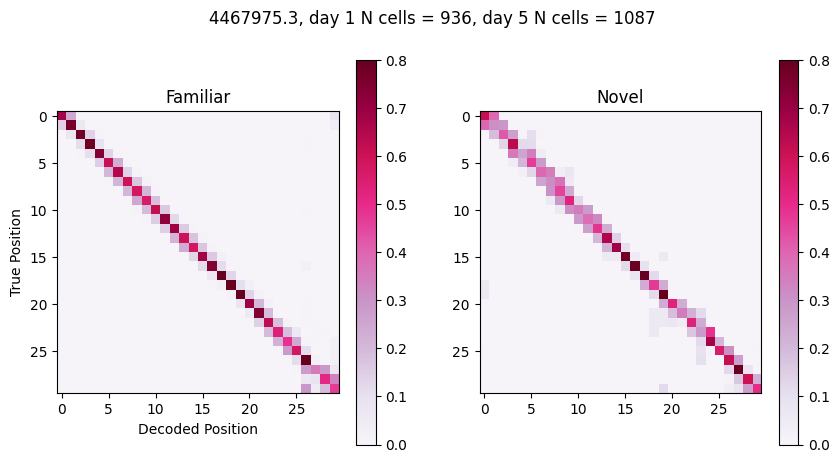

In [4]:
fig, ax = plt.subplots(1,2, figsize= [10, 5])
mouse = ko_mice[2]

sess = u.load_single_day(mouse,0)
nov_post = stx.naive_bayes.crossval(sess,nov=True)
ncells_0 = sess.timeseries['F_dff'].shape[0]

sess = u.load_single_day(mouse,4)
fam_post = stx.naive_bayes.crossval(sess,nov=False)
ncells_4 = sess.timeseries['F_dff'].shape[0]

    
h = ax[0].imshow(fam_post.mean(axis=0), cmap='PuRd', vmin=0,vmax=.8)
plt.colorbar(h, ax = ax[0], shrink=1.)
h = ax[1].imshow(nov_post.mean(axis=0), cmap='PuRd', vmin=0,vmax=.8)
plt.colorbar(h, ax = ax[1], shrink =1.)

fig.suptitle(f"{mouse}, day 1 N cells = {ncells_0}, day 5 N cells = {ncells_4}")
ax[0].set_title("Familiar")
ax[0].set_xlabel('Decoded Position')
ax[0].set_ylabel('True Position')

ax[1].set_title("Novel")

fig.savefig(figdir / f"{mouse}_naive_bayes_examples.pdf", bbox_inches='tight')

{'date': '26_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 11, 'novel_arm': -1, 'exp_day': 1}
{'date': '30_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 32, 'novel_arm': -1, 'exp_day': 5}


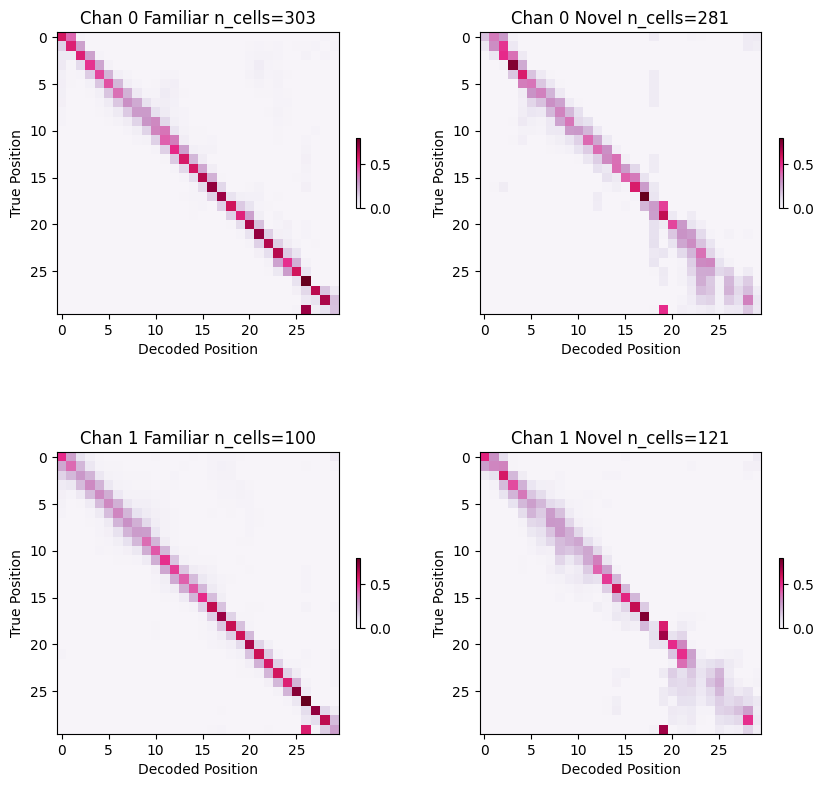

In [5]:
fig, ax = plt.subplots(2,2, figsize= [10,10])
mouse = sparse_mice[2]

sess = u.load_single_day(mouse,0)
nov_post_chan0 = stx.naive_bayes.crossval(sess,nov=True, chan='channel_0')
nov_post_chan1 = stx.naive_bayes.crossval(sess,nov=True, chan='channel_1')
ncells_0_chan0 = sess.timeseries['channel_0_F_dff'].shape[0]
ncells_0_chan1 = sess.timeseries['channel_1_F_dff'].shape[0]

sess = u.load_single_day(mouse,4)
fam_post_chan0 = stx.naive_bayes.crossval(sess,nov=False, chan='channel_0')
fam_post_chan1 = stx.naive_bayes.crossval(sess,nov=False, chan='channel_1')
ncells_4_chan0 = sess.timeseries['channel_0_F_dff'].shape[0]
ncells_4_chan1 = sess.timeseries['channel_1_F_dff'].shape[0]

h = ax[0,0].imshow(fam_post_chan0.mean(axis=0), cmap='PuRd', vmin=0,vmax=.8)
plt.colorbar(h, ax = ax[0,0], shrink=.2)
h = ax[0,1].imshow(nov_post_chan0.mean(axis=0), cmap='PuRd', vmin=0,vmax=.8)
plt.colorbar(h, ax = ax[0,1], shrink =.2)

h = ax[1,0].imshow(fam_post_chan1.mean(axis=0), cmap='PuRd', vmin=0,vmax=.8)
plt.colorbar(h, ax = ax[1,0], shrink=.2)
h = ax[1,1].imshow(nov_post_chan1.mean(axis=0), cmap='PuRd', vmin=0,vmax=.8)
plt.colorbar(h, ax = ax[1,1], shrink =.2)



ax[0,0].set_title(f"Chan 0 Familiar n_cells={ncells_4_chan0}")
ax[0,0].set_xlabel('Decoded Position')
ax[0,0].set_ylabel('True Position')

ax[0,1].set_title(f"Chan 0 Novel n_cells={ncells_0_chan0}")
ax[0,1].set_xlabel('Decoded Position')
ax[0,1].set_ylabel('True Position')


ax[1,0].set_title(f"Chan 1 Familiar n_cells={ncells_4_chan1}")
ax[1,0].set_xlabel('Decoded Position')
ax[1,0].set_ylabel('True Position')

ax[1,1].set_title(f"Chan 1 Novel n_cells={ncells_0_chan1}")
ax[1,1].set_xlabel('Decoded Position')
ax[1,1].set_ylabel('True Position')


fig.savefig(figdir / f"{mouse}_naive_bayes_examples.pdf", bbox_inches='tight')
# fig.suptitle(f"{mouse},channel 0: N cells = {ncells}")


# cross val with matched model size

In [9]:
ctrl_alldays_crossval = stx.naive_bayes.run_alldays_baseline_crossval(ctrl_mice, 128)
ko_alldays_crossval = stx.naive_bayes.run_alldays_baseline_crossval(ko_mice, 128)

mouse 4467331.1
{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 0}


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/naive_bayes.py:28: RuntimeWarning: All-NaN slice encountered
  trial_mat -= np.nanmin(trial_mat,axis=-1,keepdims=True)


{'date': '30_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 7, 'novel_arm': -1, 'ravel_ind': 1}


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/naive_bayes.py:28: RuntimeWarning: All-NaN slice encountered
  trial_mat -= np.nanmin(trial_mat,axis=-1,keepdims=True)


{'date': '01_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'ravel_ind': 2}


...

/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/naive_bayes.py:28: RuntimeWarning: All-NaN slice encountered
  trial_mat -= np.nanmin(trial_mat,axis=-1,keepdims=True)


{'date': '23_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 4}


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/naive_bayes.py:28: RuntimeWarning: All-NaN slice encountered
  trial_mat -= np.nanmin(trial_mat,axis=-1,keepdims=True)


{'date': '23_10_2021', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 5}


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/naive_bayes.py:28: RuntimeWarning: All-NaN slice encountered
  trial_mat -= np.nanmin(trial_mat,axis=-1,keepdims=True)


In [ ]:
df = {
     'ko': [],
     'day': [],
     'nov': [],
     'err': [],
     'mouse': [],
     }


days = np.arange(6)



for i, day in enumerate(days):
    for nov in ('fam','nov'):
        for m, mouse in enumerate(ko_mice):
            base_err = 10*stx.naive_bayes.abs_err(ko_alldays_crossval[mouse][day][nov])
            df['mouse'].append(mouse)
            df['ko'].append(True)
            df['nov'].append(nov=='nov')
            df['err'].append(base_err.mean())
            df['day'].append(day)
        for m, mouse in enumerate(ctrl_mice):
            base_err = 10*stx.naive_bayes.abs_err(ctrl_alldays_crossval[mouse][day][nov])
            df['mouse'].append(mouse)
            df['ko'].append(False)
            df['nov'].append(nov=='nov')
            df['err'].append(base_err.mean())
            df['day'].append(day)
                        
df = pd.DataFrame(df)


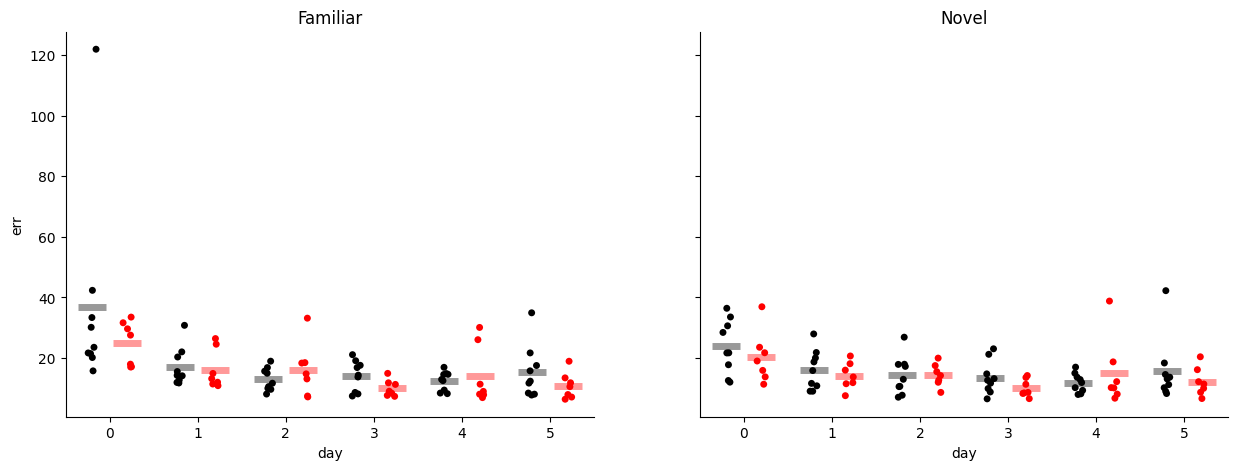

In [35]:
fig, ax = plt.subplots(1,2, sharey=True, figsize =[15,5])

sns.stripplot(
              data=df.loc[df['nov']==False,:],
              x='day',
              y='err',
              hue='ko',
              hue_order = [False, True],
              palette = ['black','red'],
              ax=ax[0],
              dodge=True, alpha=1., legend=False,
)

sns.pointplot(data=df.loc[df['nov']==False,:],
              x='day',
              y='err',
              errorbar=None,
              hue='ko',
              hue_order = [False, True],
              dodge = .4,
              palette = ['black','red'],
              ax=ax[0],
              linestyles="none",
              marker="_", markersize=20, markeredgewidth=5, legend=False, alpha=.4,
              )

sns.stripplot(
              data=df.loc[df['nov']==True,:],
              x='day',
              y='err',
              hue='ko',
              hue_order = [False, True],
              palette = ['black','red'],
              ax=ax[1],
              dodge=True, alpha=1., legend=False,
)

sns.pointplot(data=df.loc[df['nov']==True,:],
              x='day',
              y='err',
              errorbar=None,
              hue='ko',
              hue_order = [False, True],
              dodge = .4,
              palette = ['black','red'],
              ax=ax[1],
              linestyles="none",
              marker="_", markersize=20, markeredgewidth=5, legend=False, alpha=.4,
              )

ax[0].set_title("Familiar")
ax[1].set_title("Novel")

for a in ax:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

fig.savefig(figdir / f"naive_bayes_summary_128cells.pdf", bbox_inches='tight')

In [30]:
aov = pg.mixed_anova(data=df[(df['nov']==False)], dv='err', between='ko', within='day', subject='mouse')
print(aov)

ph = pg.pairwise_tests(df[df['nov']==False], dv='err', between='ko', within='day', subject='mouse',
                     padjust='holm',parametric=True)
print(ph)

aov = pg.mixed_anova(data=df[(df['nov']==True)], dv='err', between='ko', within='day', subject='mouse')
print(aov)

ph = pg.pairwise_tests(df[df['nov']==True], dv='err', between='ko', within='day', subject='mouse',
                     padjust='holm',parametric=True)
print(ph)

        Source           SS  DF1  DF2          MS         F     p-unc  \
0           ko   175.494006    1   14  175.494006  0.717676  0.411156   
1          day  4289.326578    5   70  857.865316  7.183302  0.000018   
2  Interaction   567.961365    5   70  113.592273  0.951161  0.453776   

   p-GG-corr       np2       eps sphericity   W-spher       p-spher  
0        NaN  0.048763       NaN        NaN       NaN           NaN  
1   0.008458  0.339102  0.276457      False  0.001985  2.767329e-11  
2        NaN  0.063618       NaN        NaN       NaN           NaN  
    Contrast day      A     B Paired Parametric         T        dof  \
0        day   -      0     1   True       True  2.492457  15.000000   
1        day   -      0     2   True       True  2.705389  15.000000   
2        day   -      0     3   True       True  3.128242  15.000000   
3        day   -      0     4   True       True  2.931735  15.000000   
4        day   -      0     5   True       True  2.839471  15.00000

In [33]:
sparse_alldays_crossval = stx.naive_bayes.run_alldays_baseline_crossval_sparse(sparse_mice, 128)

mouse SparseKO_02
{'date': '16_11_2024', 'scene': 'YMaze_LNovel', 'session': 4, 'scan': 14, 'novel_arm': -1, 'exp_day': 1}


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/naive_bayes.py:28: RuntimeWarning: All-NaN slice encountered
  trial_mat -= np.nanmin(trial_mat,axis=-1,keepdims=True)


{'date': '17_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 25, 'novel_arm': -1, 'exp_day': 2}


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/naive_bayes.py:28: RuntimeWarning: All-NaN slice encountered
  trial_mat -= np.nanmin(trial_mat,axis=-1,keepdims=True)


{'date': '18_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 18, 'novel_arm': -1, 'exp_day': 3}


...

/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/naive_bayes.py:28: RuntimeWarning: All-NaN slice encountered
  trial_mat -= np.nanmin(trial_mat,axis=-1,keepdims=True)


{'date': '29_05_2025', 'scene': 'YMaze_LNovel', 'session': 3, 'scan': 14, 'novel_arm': -1, 'exp_day': 5}


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/naive_bayes.py:28: RuntimeWarning: All-NaN slice encountered
  trial_mat -= np.nanmin(trial_mat,axis=-1,keepdims=True)


{'date': '30_05_2025', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 37, 'novel_arm': -1, 'exp_day': 6}


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/naive_bayes.py:28: RuntimeWarning: All-NaN slice encountered
  trial_mat -= np.nanmin(trial_mat,axis=-1,keepdims=True)


In [44]:
df_sparse = {
     'chan': [],
     'day': [],
     'nov': [],
     'err': [],
     'mouse': [],
     }

days = np.arange(6)

for i, day in enumerate(days):
    for nov in ('fam','nov'):
        for chan in ('channel_0','channel_1'):
            for m, mouse in enumerate(sparse_mice):
                if mouse == 'SparseKO_09' and day ==2:
                    continue
                
                base_err = 10*stx.naive_bayes.abs_err(sparse_alldays_crossval[mouse][day][chan][nov])
                df_sparse['mouse'].append(mouse)
                df_sparse['chan'].append(chan)
                df_sparse['nov'].append(nov=='nov')
                df_sparse['err'].append(base_err.mean())
                df_sparse['day'].append(day)
        
df_sparse = pd.DataFrame(df_sparse)


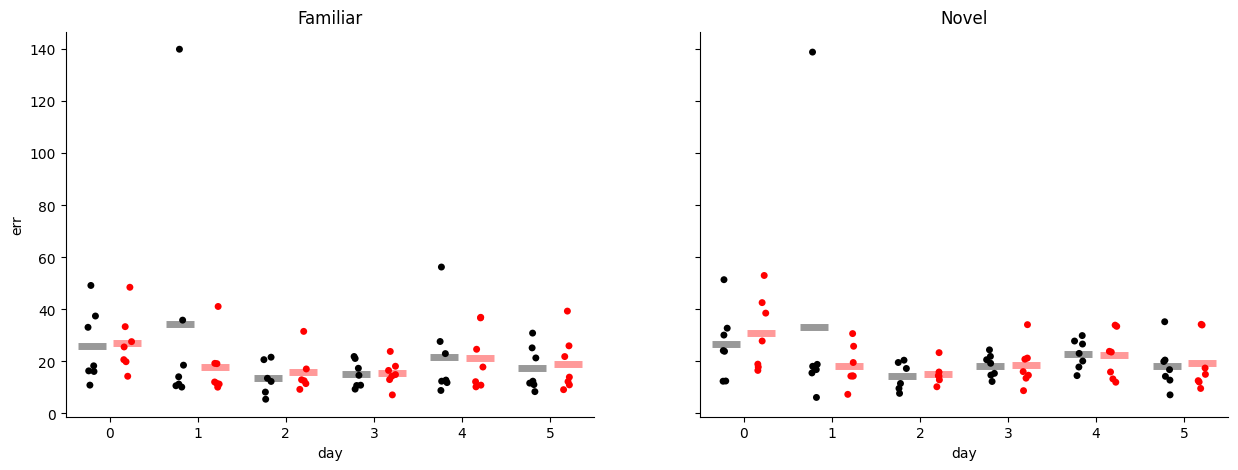

In [47]:
fig, ax = plt.subplots(1,2, sharey=True, figsize =[15,5])

sns.stripplot(
              data=df_sparse.loc[df_sparse['nov']==False,:],
              x='day',
              y='err',
              hue='chan',
              hue_order = ['channel_1', 'channel_0'],
              palette = ['black','red'],
              ax=ax[0],
              dodge=True, alpha=1., legend=False,
)

sns.pointplot(data=df_sparse.loc[df_sparse['nov']==False,:],
              x='day',
              y='err',
              errorbar=None,
              hue='chan',
              hue_order = ['channel_1', 'channel_0'],
              dodge = .4,
              palette = ['black','red'],
              ax=ax[0],
              linestyles="none",
              marker="_", markersize=20, markeredgewidth=5, legend=False, alpha=.4,
              )

sns.stripplot(
              data=df_sparse.loc[df_sparse['nov']==True,:],
              x='day',
              y='err',
              hue='chan',
              hue_order = ['channel_1', 'channel_0'],
              palette = ['black','red'],
              ax=ax[1],
              dodge=True, alpha=1., legend=False,
)

sns.pointplot(data=df_sparse.loc[df_sparse['nov']==True,:],
              x='day',
              y='err',
              errorbar=None,
              hue='chan',
              hue_order = ['channel_1', 'channel_0'],
              dodge = .4,
              palette = ['black','red'],
              ax=ax[1],
              linestyles="none",
              marker="_", markersize=20, markeredgewidth=5, legend=False, alpha=.4,
              )

ax[0].set_title("Familiar")
ax[1].set_title("Novel")

for a in ax:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
fig.savefig(figdir / f"sparse_naive_bayes_summary_max128cells.pdf", bbox_inches='tight')